In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [3]:
from src.config import SimConfig, EnvConfig
from src.utils.data_processing import load_and_cache_entire_fleet
from src.utils.evaluation import VoyageBenchmarker
from src.utils.plotting import plot_markov_matrix

In [4]:
env = EnvConfig()
fleet_data = load_and_cache_entire_fleet(env)

Binary cache not found. Parsing raw .mat files with scale_factor=0.75...
 -> Day 01 successfully parsed and scaled.
 -> Day 02 successfully parsed and scaled.
 -> Day 03 successfully parsed and scaled.
 -> Day 04 successfully parsed and scaled.
 -> Day 05 successfully parsed and scaled.
 -> Day 06 successfully parsed and scaled.
 -> Day 07 successfully parsed and scaled.
 -> Day 08 successfully parsed and scaled.
 -> Day 09 successfully parsed and scaled.
 -> Day 10 successfully parsed and scaled.
 -> Day 11 successfully parsed and scaled.
 -> Day 12 successfully parsed and scaled.
 -> Day 13 successfully parsed and scaled.
 -> Day 14 successfully parsed and scaled.
Compressing and writing data to fleet_data_cache_scale_0.75.npz...
All operational days scaled, cached in RAM, and written to disk.


 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


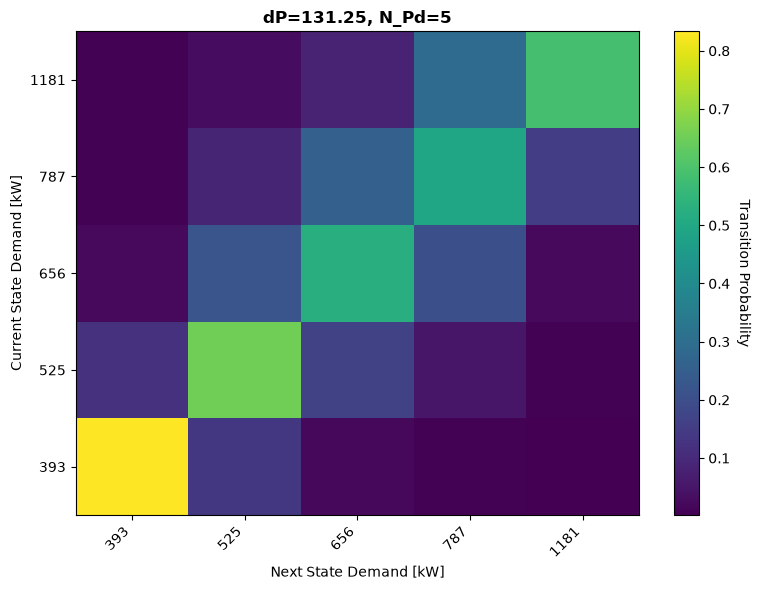

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


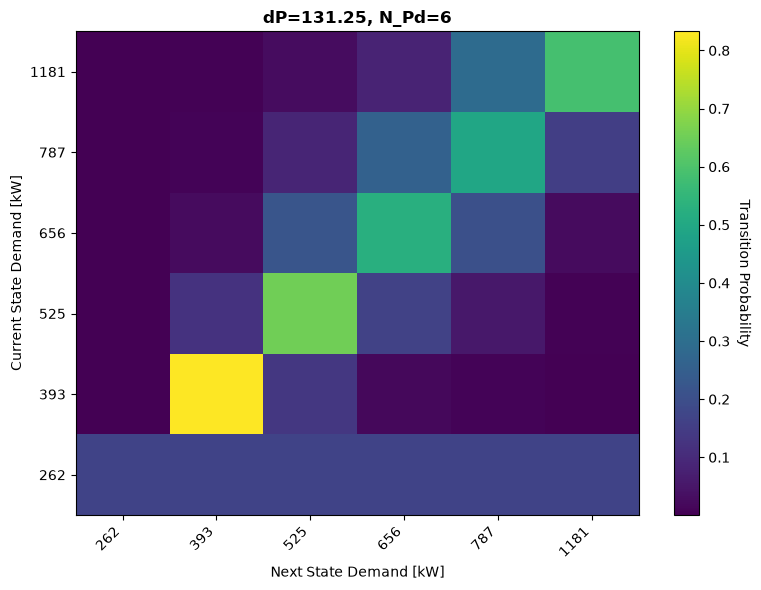

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


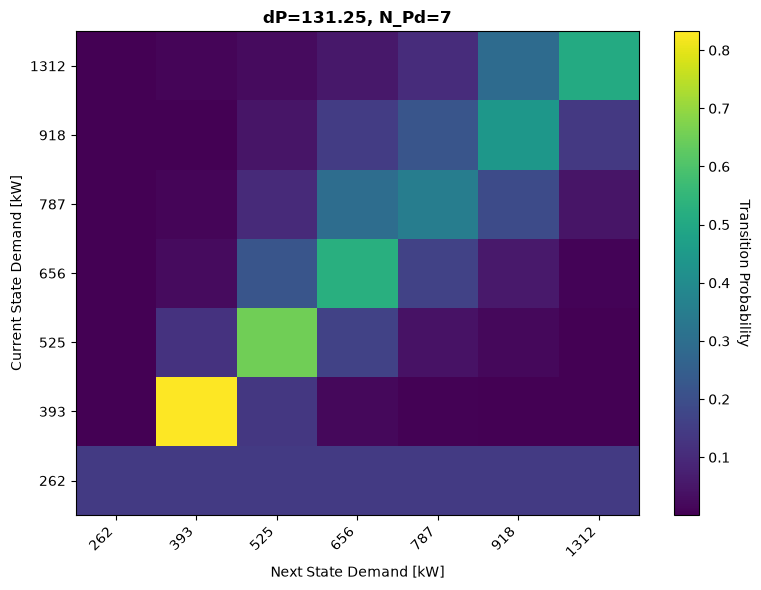

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


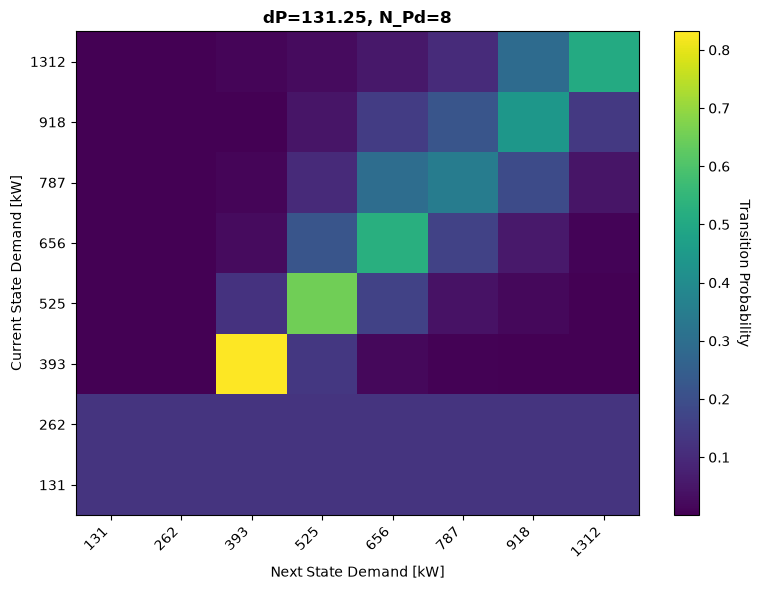

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


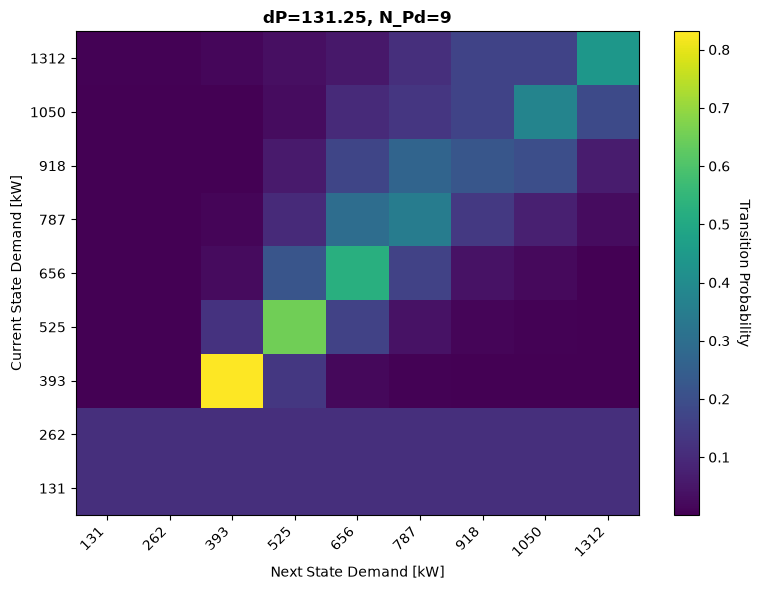

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


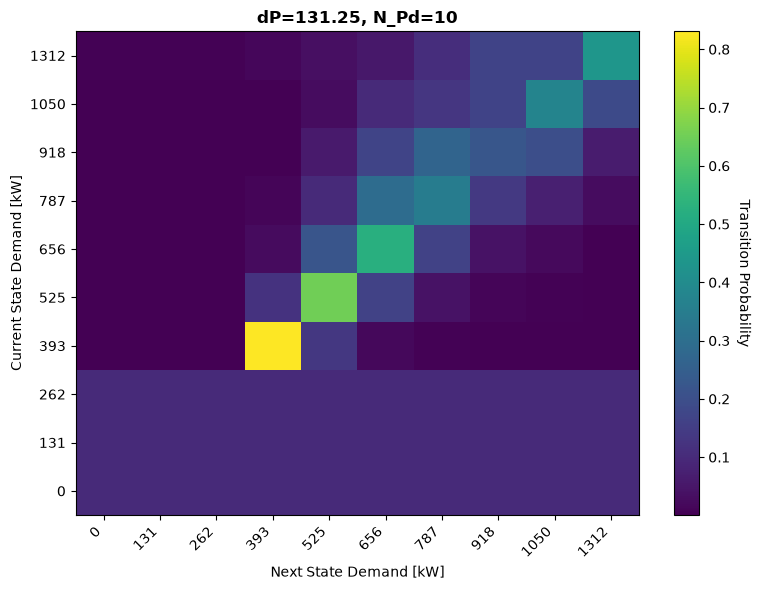

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


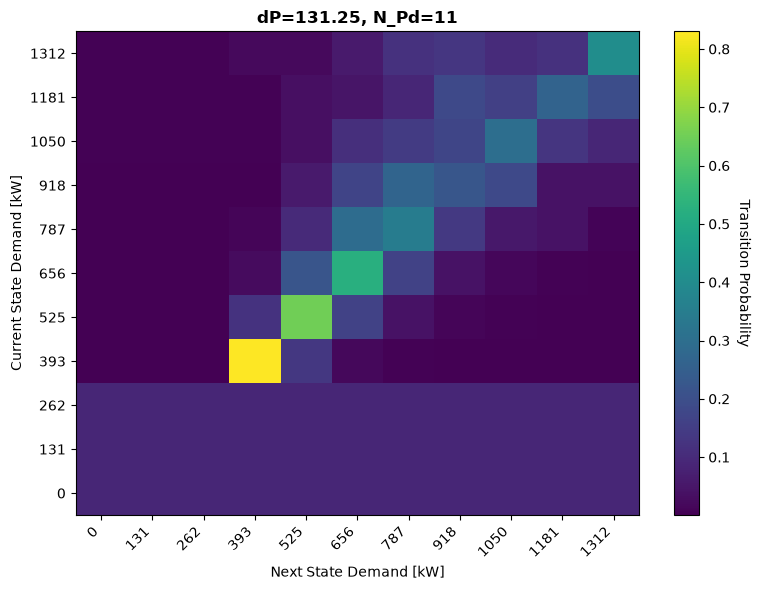

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


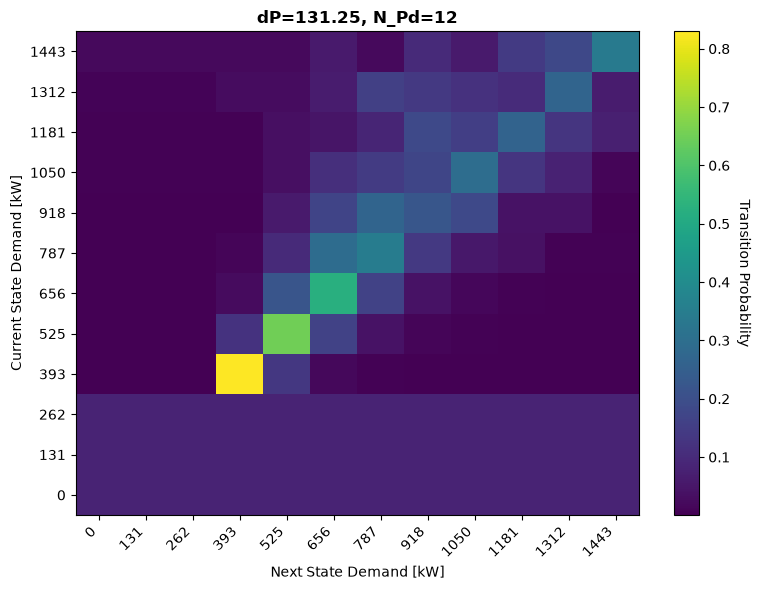

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


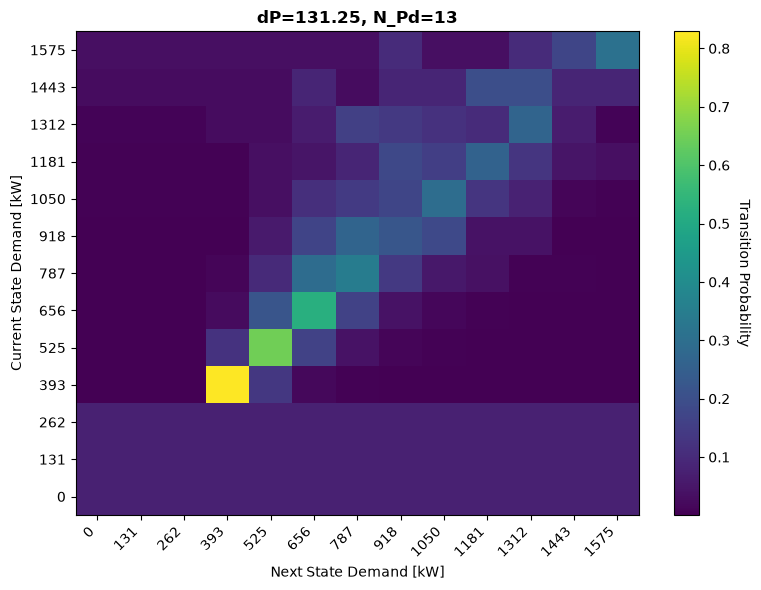

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


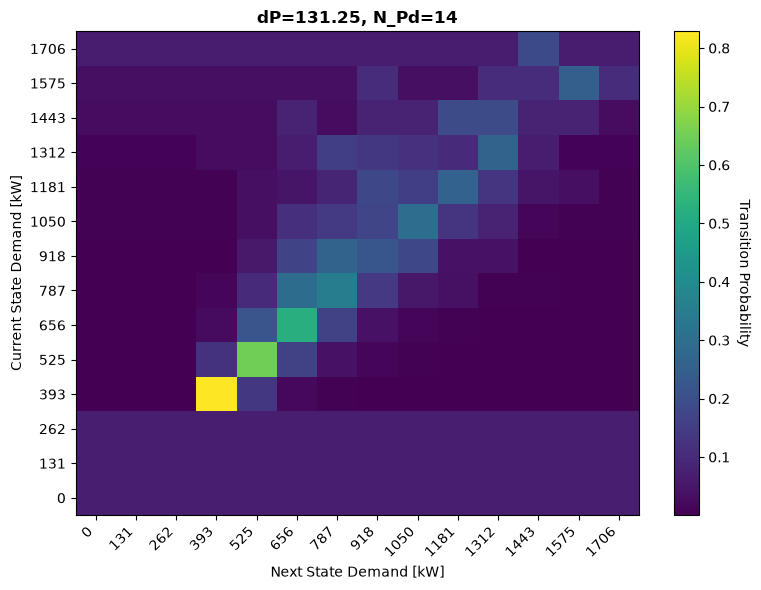

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


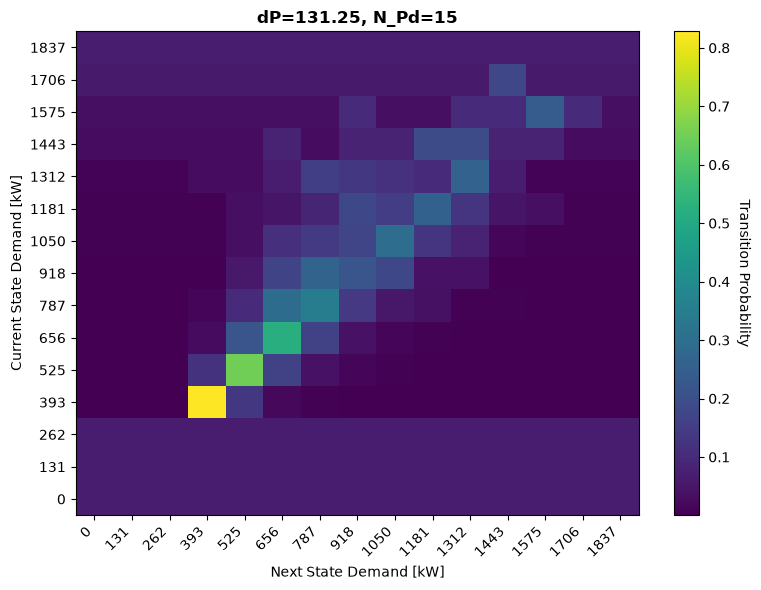

In [7]:
exclude_days = [1,2,3]
train_days = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
dP = 131.25
for i in range(5, 16):
    config = SimConfig(dP=dP, N_Pd=i, verbose=False)
    benchmarker = VoyageBenchmarker(fleet_data, env, config, exclude_days)
    mc_model, _, _ = benchmarker._get_or_compute_models(train_days, solver_cls=None, horizon_length=1)
    plot_markov_matrix(mc_model, title=f"dP={dP}, N_Pd={i}")
